# Chapter 12: Principal Component Analysis

MATH 4230 Capstone Project  
Dataset: Student Lifestyle, Mental Health and Burnout Insight

<div style="text-align:center; font-style:italic;">
Principal component analysis reduces the student wellness feature matrix into a smaller set of independent dimensions, showing whether the survey contains overlapping signals that can be summarized more efficiently.
</div>

## Setup

In [15]:
# Standard library
import os
import warnings

# Data science stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn
from sklearn.decomposition import PCA

# Settings
warnings.filterwarnings("ignore")
RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_style("whitegrid")

# Output directories
FIGURES_DIR = "../figures/ch12/"
RESULTS_DIR = "../results/ch12/"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Setup complete.")
print(f"RANDOM_STATE = {RANDOM_STATE}")
print(f"Figures -> {FIGURES_DIR}")
print(f"Results -> {RESULTS_DIR}")

Setup complete.
RANDOM_STATE = 230
Figures -> ../figures/ch12/
Results -> ../results/ch12/


## §1. The Question

Do the final standardized student wellness features reduce to a smaller number of meaningful underlying dimensions, and how much of the total variation in student profiles do the top two or three dimensions capture?

The original survey variables are represented in the Chapter 2 feature matrix after preprocessing. Because categorical variables were dummy-encoded, the PCA input contains 19 final feature columns.

## §2. Method in Brief

Principal component analysis uses variance decomposition to rewrite the original feature matrix as a new set of orthogonal components. Each component is an eigenvector direction that captures as much remaining variation as possible while staying uncorrelated with the components before it.

The loadings show how strongly each original feature contributes to each principal component. The explained variance ratio tells how much of the total variation is captured by each component, which makes PCA useful for dimensionality reduction.

## §3. Why This Method?

Chapter 4 showed that several predictors are strongly correlated, which means many variables may be measuring overlapping parts of the same student wellness profile. PCA is the right tool because it does not need a target variable and can reveal whether the feature set contains a smaller number of underlying dimensions. A simpler correlation table can show pairs of related variables, but it cannot summarize the full multivariable structure into independent components. If the leading components have clear labels, PCA can also suggest a shorter survey structure by identifying which groups of variables carry the most shared information.

## §4. Data Setup

This chapter uses the standardized feature arrays created in Chapter 2. PCA is unsupervised, so neither the burnout score nor the risk level target is used during fitting. The training set is used to learn the component directions, and the test set is projected into the same component space only to check whether the variance structure looks similar on held-out data.

Although the project question refers to the student wellness survey variables, the actual PCA input is the final Chapter 2 feature matrix. This matrix contains 19 standardized columns because `gender` and `academic_year` were dummy-encoded during preprocessing.

In [16]:
# Load arrays from Chapter 2
X_train = np.load("../results/X_train.npy")
X_test = np.load("../results/X_test.npy")
feature_names = joblib.load("../results/feature_names.pkl")

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Number of saved feature names: {len(feature_names)}")
print()
print("Feature names:")
for i, name in enumerate(feature_names, 1):
    print(f"{i:2d}. {name}")

X_train shape: (140000, 19)
X_test shape : (40000, 19)
Number of saved feature names: 19

Feature names:
 1. age
 2. study_hours_per_day
 3. exam_pressure
 4. academic_performance
 5. stress_level
 6. anxiety_score
 7. depression_score
 8. sleep_hours
 9. physical_activity
10. social_support
11. screen_time
12. internet_usage
13. financial_stress
14. family_expectation
15. gender_Male
16. gender_Other
17. academic_year_2
18. academic_year_3
19. academic_year_4


In [17]:
# PCA will use the standardized feature matrix from Chapter 2.
# The notebook uses 16 components as requested for the chapter.
# If the saved matrix has fewer than 16 columns, it safely uses the maximum available.
N_COMPONENTS = min(16, X_train.shape[1])

print(f"PCA components requested: 16")
print(f"PCA components used     : {N_COMPONENTS}")

PCA components requested: 16
PCA components used     : 16


## §5. Analysis

In [18]:
# Fit PCA on training features only
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Explained variance by component:")
for i, (ev, cv) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i:02d}: explained={ev:.4f}, cumulative={cv:.4f}")

Explained variance by component:
PC01: explained=0.1663, cumulative=0.1663
PC02: explained=0.0996, cumulative=0.2659
PC03: explained=0.0861, cumulative=0.3520
PC04: explained=0.0703, cumulative=0.4223
PC05: explained=0.0701, cumulative=0.4924
PC06: explained=0.0630, cumulative=0.5554
PC07: explained=0.0612, cumulative=0.6166
PC08: explained=0.0529, cumulative=0.6695
PC09: explained=0.0528, cumulative=0.7223
PC10: explained=0.0525, cumulative=0.7748
PC11: explained=0.0522, cumulative=0.8270
PC12: explained=0.0477, cumulative=0.8747
PC13: explained=0.0423, cumulative=0.9169
PC14: explained=0.0220, cumulative=0.9389
PC15: explained=0.0208, cumulative=0.9597
PC16: explained=0.0175, cumulative=0.9772


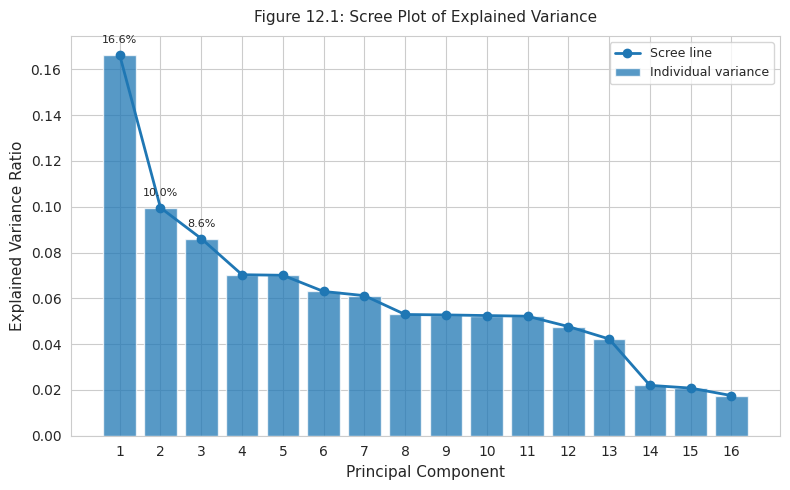

Saved: ../figures/ch12/figure_12_1_scree_plot.png


In [19]:
# Figure 12.1: Scree plot
# Bars make the individual explained variance easier to compare across components.

component_nums = np.arange(1, N_COMPONENTS + 1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(component_nums, explained, alpha=0.75, label="Individual variance")
ax.plot(component_nums, explained, marker="o", linewidth=2, label="Scree line")

for i in range(min(3, N_COMPONENTS)):
    ax.text(
        component_nums[i],
        explained[i] + 0.005,
        f"{explained[i] * 100:.1f}%",
        ha="center",
        fontsize=8
    )

ax.set_xlabel("Principal Component", fontsize=11)
ax.set_ylabel("Explained Variance Ratio", fontsize=11)
ax.set_title("Figure 12.1: Scree Plot of Explained Variance", fontsize=11, pad=10)
ax.set_xticks(component_nums)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_121 = os.path.join(FIGURES_DIR, "figure_12_1_scree_plot.png")
plt.savefig(fig_path_121, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_121}")

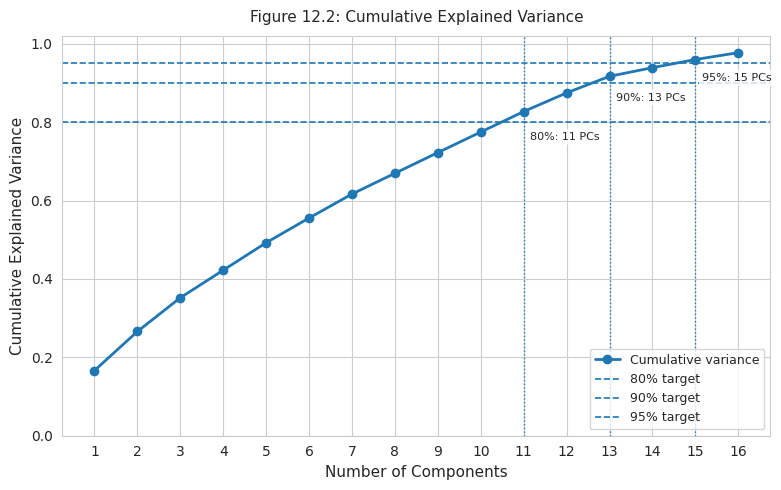

Saved: ../figures/ch12/figure_12_2_cumulative_variance.png
Table 12.1: Components needed to reach common explained-variance targets.


,Target Explained Variance,Components Needed
0,80%,11
1,90%,13
2,95%,15


In [20]:
# Figure 12.2: Cumulative explained variance
# Vertical markers show the number of components needed to reach 80%, 90%, and 95%.

thresholds = [0.80, 0.90, 0.95]
threshold_results = {}

for threshold in thresholds:
    reached = np.where(cumulative >= threshold)[0]
    if len(reached) > 0:
        threshold_results[f"{int(threshold * 100)}%"] = int(reached[0] + 1)
    else:
        threshold_results[f"{int(threshold * 100)}%"] = f"> {N_COMPONENTS}"

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(component_nums, cumulative, marker="o", linewidth=2, label="Cumulative variance")

for threshold in thresholds:
    label = f"{int(threshold * 100)}%"
    ax.axhline(threshold, linestyle="--", linewidth=1.2, label=f"{label} target")

    if isinstance(threshold_results[label], int):
        x_pos = threshold_results[label]
        ax.axvline(x_pos, linestyle=":", linewidth=1.0)
        ax.text(
            x_pos + 0.15,
            threshold - 0.045,
            f"{label}: {x_pos} PCs",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8)
        )

ax.set_xlabel("Number of Components", fontsize=11)
ax.set_ylabel("Cumulative Explained Variance", fontsize=11)
ax.set_title("Figure 12.2: Cumulative Explained Variance", fontsize=11, pad=10)
ax.set_xticks(component_nums)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
fig_path_122 = os.path.join(FIGURES_DIR, "figure_12_2_cumulative_variance.png")
plt.savefig(fig_path_122, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_122}")

print("Table 12.1: Components needed to reach common explained-variance targets.")
threshold_table = pd.DataFrame({
    "Target Explained Variance": list(threshold_results.keys()),
    "Components Needed": list(threshold_results.values())
})
display(threshold_table)

In [21]:
# Save Table 12.1 for later use in the report

threshold_table_path = os.path.join(RESULTS_DIR, "pca_threshold_table.csv")
threshold_table.to_csv(threshold_table_path, index=False)

print(f"Saved: {threshold_table_path}")

Saved: ../results/ch12/pca_threshold_table.csv


In [22]:
# Loadings table for PC1 through PC5
top_pc_count = min(5, N_COMPONENTS)

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i}" for i in range(1, N_COMPONENTS + 1)]
)

loadings_top5 = loadings.iloc[:, :top_pc_count].copy()

print("PCA loadings for top 5 principal components:")
print(loadings_top5.round(4).to_string())

PCA loadings for top 5 principal components:
                         PC1     PC2     PC3     PC4     PC5
age                  -0.0022  0.0002 -0.0010 -0.0194  0.0232
study_hours_per_day   0.3280  0.0025  0.5707  0.0039  0.0107
exam_pressure         0.3591  0.0027  0.4631 -0.0002  0.0049
academic_performance  0.1095  0.0016  0.4020  0.0065  0.0165
stress_level          0.5130 -0.0013 -0.1629 -0.0014 -0.0055
anxiety_score         0.4510 -0.0011 -0.1665 -0.0025 -0.0077
depression_score      0.4051  0.0028 -0.2068  0.0010  0.0080
sleep_hours          -0.1366  0.0010  0.1663  0.0038  0.0054
physical_activity    -0.0899  0.0005  0.1178 -0.0008  0.0120
social_support       -0.0656 -0.0060  0.1212 -0.0085 -0.0176
screen_time          -0.0014  0.7069 -0.0020 -0.0011 -0.0150
internet_usage       -0.0001  0.7069 -0.0033  0.0003 -0.0143
financial_stress      0.2400 -0.0031 -0.3107  0.0015  0.0019
family_expectation    0.1793 -0.0021 -0.2192 -0.0027 -0.0159
gender_Male           0.0027  0.0043  0.

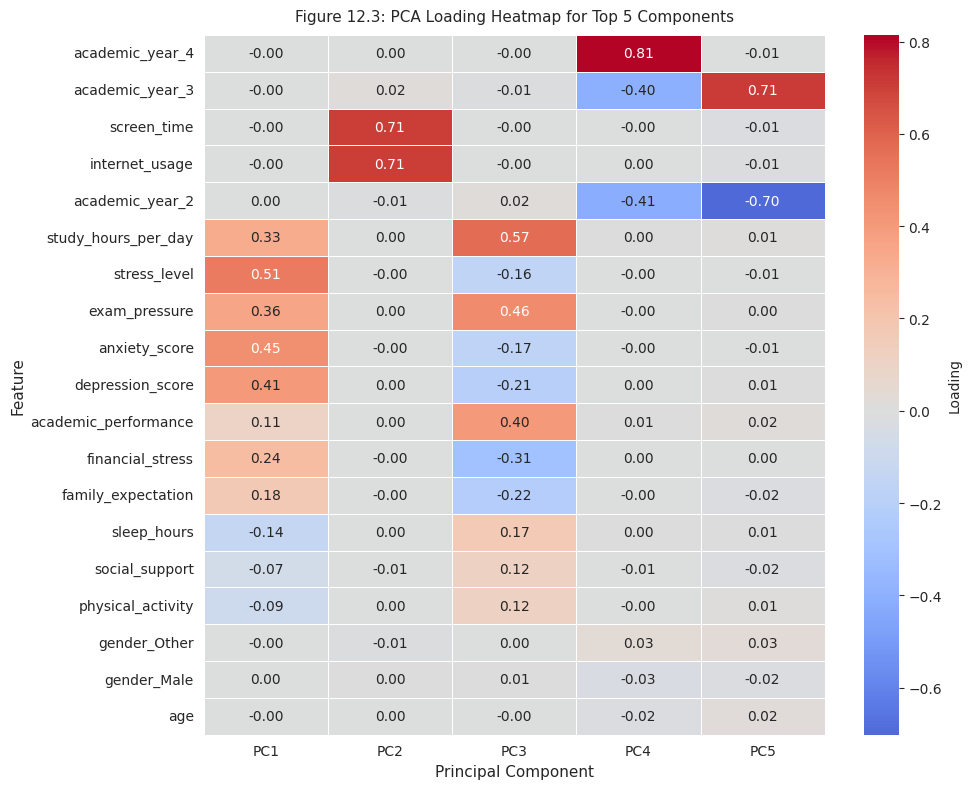

Saved: ../figures/ch12/figure_12_3_loadings_heatmap.png


In [23]:
# Figure 12.3: Heatmap of loadings for top 5 PCs
# Features are sorted by their strongest absolute loading across PC1 through PC5.

plot_order = loadings_top5.abs().max(axis=1).sort_values(ascending=False).index
loadings_top5_plot = loadings_top5.loc[plot_order]

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    loadings_top5_plot,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"label": "Loading"},
    ax=ax
)

ax.set_title("Figure 12.3: PCA Loading Heatmap for Top 5 Components", fontsize=11, pad=10)
ax.set_xlabel("Principal Component", fontsize=11)
ax.set_ylabel("Feature", fontsize=11)

plt.tight_layout()
fig_path_123 = os.path.join(FIGURES_DIR, "figure_12_3_loadings_heatmap.png")
plt.savefig(fig_path_123, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_123}")

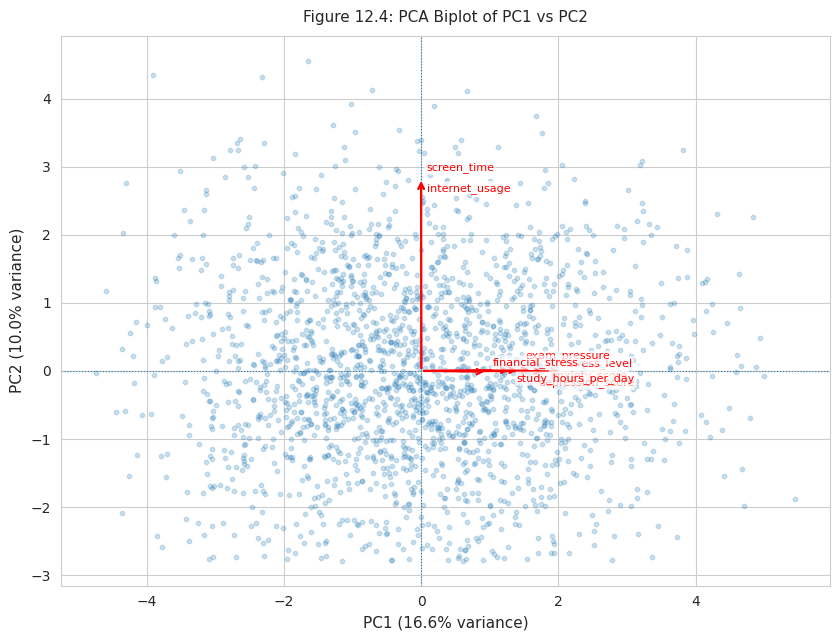

Saved: ../figures/ch12/figure_12_4_biplot.png


In [24]:
# Figure 12.4: Biplot of PC1 vs PC2 using a 2,000-point sample
# Red arrows show the loading directions for the strongest features.

sample_n = min(2000, X_train_pca.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_train_pca.shape[0], size=sample_n, replace=False)

pc1 = X_train_pca[sample_idx, 0]
pc2 = X_train_pca[sample_idx, 1]

fig, ax = plt.subplots(figsize=(8.5, 6.5))

ax.scatter(pc1, pc2, s=10, alpha=0.22)
ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)", fontsize=11)
ax.set_title("Figure 12.4: PCA Biplot of PC1 vs PC2", fontsize=11, pad=10)

# Loading arrows for the strongest features across PC1 and PC2
arrow_scale = 4.0
pc12_strength = np.sqrt(loadings["PC1"] ** 2 + loadings["PC2"] ** 2)
top_arrow_features = pc12_strength.sort_values(ascending=False).head(8).index

# Manual offsets reduce label overlap for the most common biplot labels.
label_offsets = {
    "screen_time": (0.08, 0.12),
    "internet_usage": (0.08, -0.18),
    "stress_level": (0.08, 0.08),
    "anxiety_score": (0.08, -0.10),
    "depression_score": (0.08, -0.22),
    "exam_pressure": (0.08, 0.16),
    "study_hours_per_day": (0.08, -0.16),
    "financial_stress": (0.08, 0.10)
}

for feature in top_arrow_features:
    x_loading = loadings.loc[feature, "PC1"] * arrow_scale
    y_loading = loadings.loc[feature, "PC2"] * arrow_scale

    ax.annotate(
        "",
        xy=(x_loading, y_loading),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle="->", color="red", lw=1.4)
    )

    dx, dy = label_offsets.get(feature, (0.06, 0.06))
    ax.text(
        x_loading + dx,
        y_loading + dy,
        feature,
        fontsize=8,
        color="red",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none")
    )

ax.axhline(0, linewidth=0.8, linestyle=":")
ax.axvline(0, linewidth=0.8, linestyle=":")

plt.tight_layout()
fig_path_124 = os.path.join(FIGURES_DIR, "figure_12_4_biplot.png")
plt.savefig(fig_path_124, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {fig_path_124}")

### Visualization Justification

The PCA biplot uses a 2,000-point sample instead of all 140,000 training rows because plotting every row would create a dense cloud that hides the loading arrows. The PCA model is still fit on the full training set; only the displayed points are sampled for readability. The red directional arrows follow the standard biplot convention: they show which original features point in the direction of PC1 and PC2.

## §6. Diagnostics and Tuning

PCA does not use hyperparameter tuning in the same way supervised models do. The main diagnostic decision is how many components are needed to explain enough variation while still reducing dimensionality. The component labels below are based on the features with the largest absolute loadings, so they are interpretations rather than fixed mathematical names.

In [25]:
# Helper functions for component labels

def top_loading_features(pc_name, n=5):
    values = loadings[pc_name]
    top = values.abs().sort_values(ascending=False).head(n).index
    return [(feature, values.loc[feature]) for feature in top]


def propose_label(features):
    names = [name for name, value in features]
    joined = " ".join(names).lower()

    academic_year_count = sum(name.startswith("academic_year") for name in names)
    gender_count = sum(name.startswith("gender") for name in names)

    if academic_year_count >= 2:
        return "Academic year contrast"
    if gender_count >= 2:
        return "Gender indicator contrast"
    if "screen_time" in names and "internet_usage" in names:
        return "Screen and internet use"
    if any(term in joined for term in ["stress", "anxiety", "depression"]):
        return "Psychological distress"
    if any(term in joined for term in ["study", "exam", "academic_performance"]):
        return "Academic pressure and performance"
    if any(term in joined for term in ["sleep", "physical", "social"]):
        return "Lifestyle and support"
    if any(term in joined for term in ["financial", "family"]):
        return "External stressors"
    if "age" in names:
        return "Age-related profile"

    return "Mixed student profile"


pc_labels = []

for i in range(1, top_pc_count + 1):
    pc_name = f"PC{i}"
    top_features = top_loading_features(pc_name, n=5)
    label = propose_label(top_features)
    top_text = "; ".join([f"{name} ({value:+.3f})" for name, value in top_features])

    pc_labels.append({
        "PC": pc_name,
        "Top Loading Features": top_text,
        "Proposed Label": label,
        "Explained Variance": round(explained[i - 1], 4)
    })

pc_label_df = pd.DataFrame(pc_labels)

print("Table 12.2: Interpreted labels for the top 5 principal components.")
display(pc_label_df)

Table 12.2: Interpreted labels for the top 5 principal components.


,PC,Top Loading Features,Proposed Label,Explained Variance
0,PC1,stress_level (+0.513); anxiety_score (+0.451);...,Psychological distress,0.1663
1,PC2,screen_time (+0.707); internet_usage (+0.707);...,Academic year contrast,0.0996
2,PC3,study_hours_per_day (+0.571); exam_pressure (+...,Psychological distress,0.0861
3,PC4,academic_year_4 (+0.815); academic_year_2 (-0....,Academic year contrast,0.0703
4,PC5,academic_year_3 (+0.710); academic_year_2 (-0....,Academic year contrast,0.0701


In [26]:
# Project X_test into the PC space and compare variance structure.
# Because the PCA basis was learned on X_train, the test projection checks whether
# held-out data has a similar distribution along the same component directions.
test_component_variance = np.var(X_test_pca, axis=0, ddof=1)
test_total_variance = np.var(X_test, axis=0, ddof=1).sum()
test_explained_ratio = test_component_variance / test_total_variance
test_cumulative = np.cumsum(test_explained_ratio)

variance_compare_df = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, N_COMPONENTS + 1)],
    "Train Explained Variance Ratio": explained.round(4),
    "Train Cumulative": cumulative.round(4),
    "Test Projected Variance Ratio": test_explained_ratio.round(4),
    "Test Projected Cumulative": test_cumulative.round(4)
})

print("Train versus test projected variance structure:")
print(variance_compare_df.to_string(index=False))

Train versus test projected variance structure:
  PC  Train Explained Variance Ratio  Train Cumulative  Test Projected Variance Ratio  Test Projected Cumulative
 PC1                          0.1663            0.1663                         0.1662                     0.1662
 PC2                          0.0996            0.2659                         0.0996                     0.2658
 PC3                          0.0861            0.3520                         0.0858                     0.3517
 PC4                          0.0703            0.4223                         0.0698                     0.4214
 PC5                          0.0701            0.4924                         0.0701                     0.4916
 PC6                          0.0630            0.5554                         0.0632                     0.5547
 PC7                          0.0612            0.6166                         0.0620                     0.6167
 PC8                          0.0529            

## §7. Findings

In [27]:
# Table 12.3: Principal component summary
# The full 16-component table is saved for Appendix C. The main chapter shows the first 8 PCs.

summary_rows = []

for i in range(1, N_COMPONENTS + 1):
    pc_name = f"PC{i}"
    top3 = top_loading_features(pc_name, n=3)
    top3_text = "; ".join([f"{name} ({value:+.3f})" for name, value in top3])
    label = propose_label(top3)

    summary_rows.append({
        "PC": pc_name,
        "Top 3 Features by Absolute Loading": top3_text,
        "Proposed Label": label,
        "Individual Explained Variance": round(explained[i - 1], 4),
        "Cumulative Explained Variance": round(cumulative[i - 1], 4)
    })

pca_summary_df = pd.DataFrame(summary_rows)
pca_summary_main_df = pca_summary_df.head(8)

print("Table 12.3: Principal component summary for the first 8 components.")
display(pca_summary_main_df)

# Save outputs
loadings_path = os.path.join(RESULTS_DIR, "pca_loadings.csv")
variance_path = os.path.join(RESULTS_DIR, "pca_variance.csv")
summary_path = os.path.join(RESULTS_DIR, "pca_summary.csv")
summary_main_path = os.path.join(RESULTS_DIR, "pca_summary_main_table.csv")
labels_path = os.path.join(RESULTS_DIR, "pca_component_labels.csv")

loadings.to_csv(loadings_path)
variance_compare_df.to_csv(variance_path, index=False)
pca_summary_df.to_csv(summary_path, index=False)
pca_summary_main_df.to_csv(summary_main_path, index=False)
pc_label_df.to_csv(labels_path, index=False)

print()
print(f"Saved: {loadings_path}")
print(f"Saved: {variance_path}")
print(f"Saved full Appendix C table: {summary_path}")
print(f"Saved main chapter table: {summary_main_path}")
print(f"Saved: {labels_path}")

Table 12.3: Principal component summary for the first 8 components.


,PC,Top 3 Features by Absolute Loading,Proposed Label,Individual Explained Variance,Cumulative Explained Variance
0,PC1,stress_level (+0.513); anxiety_score (+0.451);...,Psychological distress,0.1663,0.1663
1,PC2,screen_time (+0.707); internet_usage (+0.707);...,Screen and internet use,0.0996,0.2659
2,PC3,study_hours_per_day (+0.571); exam_pressure (+...,Academic pressure and performance,0.0861,0.3520
3,PC4,academic_year_4 (+0.815); academic_year_2 (-0....,Academic year contrast,0.0703,0.4223
4,PC5,academic_year_3 (+0.710); academic_year_2 (-0....,Academic year contrast,0.0701,0.4924
5,PC6,gender_Male (+0.701); gender_Other (-0.701); s...,Gender indicator contrast,0.0630,0.5554
6,PC7,social_support (+0.861); depression_score (-0....,Psychological distress,0.0612,0.6166
7,PC8,physical_activity (+0.679); sleep_hours (-0.55...,Lifestyle and support,0.0529,0.6695



Saved: ../results/ch12/pca_loadings.csv
Saved: ../results/ch12/pca_variance.csv
Saved full Appendix C table: ../results/ch12/pca_summary.csv
Saved main chapter table: ../results/ch12/pca_summary_main_table.csv
Saved: ../results/ch12/pca_component_labels.csv


The first two or three components show how much of the total student profile variation can be summarized in a low-dimensional view. If the top components explain only a modest share of the variance, then the survey contains several distinct dimensions that should not be collapsed too aggressively. If the top components explain a large share, then a shorter survey could focus on the strongest loading features from those components.

### Appendix C Placement

The complete 16-component PCA summary table should be placed in Appendix C because it is too long for the main chapter. The main chapter should show Table 12.3 with the first 8 components, while Appendix Table C.12.1 can contain the full `pca_summary.csv` output.

## §8. Real-World Decision

If a university could only collect a reduced survey, it should preserve the latent dimensions represented by the strongest early components rather than keeping variables at random. The reduced survey should include variables that represent psychological distress, lifestyle behavior, academic pressure, and external stressors because those domains repeatedly appear across earlier chapters and are likely to capture different parts of student risk. The best representative variables are the ones with large absolute loadings in the leading components, since they carry the most information about the main directions of variation in student profiles.

## §9. Caveats and Limitations

PCA components are mathematical directions, so the labels assigned to them are interpretive and may change depending on the analyst. The signs of loadings are also arbitrary, meaning a component can be multiplied by -1 without changing its meaning. Finally, dimensionality reduction loses information, and some lower-variance features may still matter for prediction or intervention even if they are not dominant in the PCA structure.

In [28]:
# Final summary
print("Chapter 12 complete. Files written:")
print()
print("Figures")
for path in [fig_path_121, fig_path_122, fig_path_123, fig_path_124]:
    print(f" {path}")
print()
print("Results")
for path in [
    threshold_table_path,
    loadings_path,
    variance_path,
    summary_path,
    summary_main_path,
    labels_path
]:
    print(f" {path}")

Chapter 12 complete. Files written:

Figures
 ../figures/ch12/figure_12_1_scree_plot.png
 ../figures/ch12/figure_12_2_cumulative_variance.png
 ../figures/ch12/figure_12_3_loadings_heatmap.png
 ../figures/ch12/figure_12_4_biplot.png

Results
 ../results/ch12/pca_threshold_table.csv
 ../results/ch12/pca_loadings.csv
 ../results/ch12/pca_variance.csv
 ../results/ch12/pca_summary.csv
 ../results/ch12/pca_summary_main_table.csv
 ../results/ch12/pca_component_labels.csv
